# Untreated CoCulture Math Modelling

This notebook fits a two-population (sensitive / resistant) competition model to untreated co-culture datasets, using theta-logistic crowding exponents (`v`) carried over from the untreated monoculture fits.

Data root (relative to project root):

- `Processed_Datasets/Untreated CoCulture/20k`
- `Processed_Datasets/Untreated CoCulture/30k`

Parameter priors (r, K, v) are taken from the untreated monoculture fits in:

- `Modelling Data Notebooks/Untreated MonoCulture/untreated_monoculture_logistic_parameters.csv`


In [12]:
using Pkg

pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations",
    "Optim",
    "Plots", "Glob"
]

for p in pkgs
    @info "Loading package $(p)"
    try
        Base.eval(Main, :(import $(Symbol(p))))
    catch e
        @warn "Package $(p) not found, attempting to add" exception=(e, catch_backtrace())
        Pkg.add(p)
        Base.eval(Main, :(import $(Symbol(p))))
    end
end

using CSV, DataFrames, Statistics
using DifferentialEquations
using Optim
using Plots
using Glob

default(linewidth = 2, legend = :right, framestyle = :box)


┌ Info: Loading package CSV
└ @ Main c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated CoCulture\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:11
┌ Info: Loading package DataFrames
└ @ Main c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated CoCulture\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:11
┌ Info: Loading package Statistics
└ @ Main c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated CoCulture\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:11
┌ Info: Loading package DifferentialEquations
└ @ Main c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated CoCulture\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:11
┌ Info: Loading package Optim
└ @ Main c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Note


## 2) Paths and configuration

Assumes this notebook lives in:

`Modelling Data Notebooks/Untreated CoCulture/`

so that `project_root = dirname(dirname(pwd()))`.


In [13]:
# 2) Paths and configuration

using CSV, DataFrames

# -----------------------------
# Project + directory structure
# -----------------------------

# Project root: one level above 'Modelling Data Notebooks'
project_root = dirname(dirname(pwd()))

raw_coculture_dir = joinpath(project_root, "Datasets", "Untreated CoCulture")
coculture_root    = joinpath(project_root, "Processed_Datasets", "Untreated CoCulture")

# Allow easy extension to other seeding densities later
seeding_levels = ("20k", "30k")
processed_coculture_dirs = [joinpath(coculture_root, s) for s in seeding_levels]

# Untreated monoculture parameter CSV (for priors / reference)
monoculture_param_path = joinpath(
    project_root,
    "Modelling Data Notebooks",
    "Untreated MonoCulture",
    "untreated_monoculture_logistic_parameters.csv",
)

@info "project_root            = $(project_root)"
@info "raw_coculture_dir       = $(raw_coculture_dir)"
@info "coculture_root          = $(coculture_root)"
@info "processed_coculture_dirs = $(processed_coculture_dirs)"
@info "monoculture_param_path  = $(monoculture_param_path)"

# -----------------------------
# Sanity checks on directories
# -----------------------------

@assert isdir(project_root)          "project_root does not exist: $project_root"
@assert isdir(raw_coculture_dir)     "Raw coculture directory missing: $raw_coculture_dir"
@assert isdir(coculture_root)        "Coculture root directory missing: $coculture_root"
@assert all(isdir, processed_coculture_dirs) "One or more processed coculture directories are missing"

# ---------------------------------------------
# Helper: recursively collect all day_averages
# ---------------------------------------------

if !@isdefined collect_day_average_files
    """
    Recursively collect all '*day_averages.csv' files under a set of roots.

    This is robust to cis/non_cis/Averages nesting and future subdirectory changes.
    """
    function collect_day_average_files(roots::Vector{String})
        files = String[]
        for r in roots
            isdir(r) || continue
            for (root, _, filelist) in walkdir(r)
                for f in filelist
                    if endswith(f, "day_averages.csv")
                        push!(files, joinpath(root, f))
                    end
                end
            end
        end
        return files
    end
end

all_day_average_files = collect_day_average_files(processed_coculture_dirs)

@assert !isempty(all_day_average_files) "No coculture day-average files found under $(processed_coculture_dirs)"

println("\nFound $(length(all_day_average_files)) coculture day-average CSVs:")
for f in sort(all_day_average_files)
    println("  - " * f)
end

# ---------------------------------------------
# Load untreated monoculture logistic parameters
# ---------------------------------------------

@assert isfile(monoculture_param_path) "Untreated monoculture parameter CSV missing: $monoculture_param_path"

available_monoculture_params = CSV.read(monoculture_param_path, DataFrame)

println("\nMonoculture reference rows: $(nrow(available_monoculture_params))")
if nrow(available_monoculture_params) > 0
    println("Sample monoculture params:")
    display(first(available_monoculture_params, min(5, nrow(available_monoculture_params))))
end


Row,File,Density,CellLine,r,K,v,SSR,BIC
,String31,String3,String15,Float64,Float64,Float64,Float64,Float64
1,A2780Naive_day_averages.csv,20k,A2780Naive,1.13666,4077.24,0.624115,1.65077e5,139.169
2,A2780cis_day_averages.csv,20k,A2780cis,0.494431,3744.54,3.95081,5.23608e5,155.329
3,A2780Naive_day_averages.csv,30k,A2780Naive,1.05452,4035.57,0.574839,304802.0,147.754
4,A2780cis_day_averages.csv,30k,A2780cis,0.46525,3840.31,3.28747,5.06275e5,154.858



Found 24 coculture day-average CSVs:
  - c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_25-75A2780cisCoUntreat_4500Thres_day_averages.csv
  - c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_25-75A2780cisCoUntreat_4500Thres_well_day_averages.csv
  - c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_50-50A2780cisCoUntreat_4500Thres_day_averages.csv
  - c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_50-50A2780cisCoUntreat_4500Thres_well_day_averages.csv
  - c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_75-25A2780cisCoUntreat_4000Thres_day_averages.csv
  - c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerG

┌ Info: project_root            = c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics
└ @ Main c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated CoCulture\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:27
┌ Info: raw_coculture_dir       = c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Datasets\Untreated CoCulture
└ @ Main c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated CoCulture\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:28
┌ Info: coculture_root          = c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture
└ @ Main c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated CoCulture\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:29
┌ Info: processed_coculture_dirs = ["c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGr


## 3) Data loading (cis + non\_cis Averages)

We load per-condition average trajectories from:

`Processed_Datasets/Untreated CoCulture/{20k,30k}/{cis,non_cis}/Averages/*.csv`

Each cis/non\_cis pair with matching mix label (e.g. `25-75`) and density
is combined into a single `CoCultureDataset`.


In [14]:
# 3) Data loading utilities + sanity plots

using CSV, DataFrames
using Plots

struct CoCultureDataset
    density::String
    mix_label::String          # e.g. "25-75"
    t::Vector{Float64}
    cis::Vector{Float64}
    non_cis::Vector{Float64}
end

# ---------------------------
# Global options
# ---------------------------

# false -> use plate-level "*_day_averages.csv" (Day, day_mean_cells, n_wells)
# true  -> use well-level  "*_well_day_averages.csv" (Day, mean_cells, ...)
const USE_WELL_LEVEL = false

# Use more specific suffixes so we distinguish day_ vs well_day_
const DAY_SUFFIX       = "_day_averages.csv"
const WELL_DAY_SUFFIX  = "_well_day_averages.csv"

wanted_suffix() = USE_WELL_LEVEL ? WELL_DAY_SUFFIX : DAY_SUFFIX

# ---------------------------
# Helpers to parse metadata
# ---------------------------

"""
Extract (density, compartment) from a full path.

Assumes structure:
    .../Untreated CoCulture/<density>/<compartment>/Averages/...
"""
function parse_density_compartment(path::AbstractString)
    parts = splitpath(path)
    idx = findfirst(==("Untreated CoCulture"), parts)
    idx === nothing && error("Could not find 'Untreated CoCulture' in path: $path")
    length(parts) >= idx + 2 || error("Path too short to extract density/compartment: $path")

    density     = parts[idx + 1]   # "20k", "30k", etc.
    compartment = parts[idx + 2]   # "cis" or "non_cis"
    return density, compartment
end

"""
Extract mix label like "25-75" from filename of the form:
    measure_25-75A2780cisCoUntreat_4500Thres_day_averages.csv
"""
function parse_mix_label(path::AbstractString)
    fname = splitpath(path)[end]
    m = match(r"measure_([0-9]+-[0-9]+)", fname)
    return m === nothing ? "unknown" : m.captures[1]
end

# ---------------------------
# Column detection + loading
# ---------------------------

"""
Given a DataFrame, detect time and count columns based on known schemas.

For your current data:
    plate-level: Day, day_mean_cells, n_wells
    well-level:  Day, Well, mean_cells, n_tiles, channel_count
"""
function detect_time_count_cols(df::DataFrame)
    names_df  = names(df)
    names_str = [lowercase(String(n)) for n in names_df]

    # time column: look for "day" or "time" in a case-insensitive way
    t_idx = findfirst(s -> s in ("day", "time"), names_str)
    t_idx === nothing && error("Could not find a suitable time column in $(names_df)")

    # count column: slightly different preference order depending on level
    if USE_WELL_LEVEL
        target_counts = ("mean_cells", "day_mean_cells", "avg_count")
    else
        target_counts = ("day_mean_cells", "mean_cells", "avg_count")
    end

    c_idx = findfirst(s -> s in target_counts, names_str)
    c_idx === nothing && error("Could not find a suitable count column in $(names_df)")

    tcol = names_df[t_idx]
    ccol = names_df[c_idx]

    return tcol, ccol
end

"""
Load a single compartment CSV and return (t, counts)
"""
function load_single_compartment(file::String)
    df = CSV.read(file, DataFrame)
    tcol, ccol = detect_time_count_cols(df)

    t      = Float64.(df[!, tcol])
    counts = Float64.(df[!, ccol])

    return t, counts
end

# ---------------------------
# Day 0 handling with mix scaling
# ---------------------------

"""
Return the Day 0 TOTAL baseline count given the density label.
Currently:
  20k -> 67
  30k -> 100
"""
function day0_total_baseline(density::String)
    density == "20k" && return 67.0
    density == "30k" && return 100.0
    error("No Day 0 baseline defined for density = $density")
end

"""
Given a mix label like "25-75" and a compartment, return the fraction
of the total baseline to assign to that compartment.

Assumes the first number in mix_label is cis, second is non_cis.
"""
function mix_fraction(mix_label::String, compartment::String)
    mix_label == "unknown" && error("Cannot compute mix fraction for mix_label='unknown'")
    parts = split(mix_label, '-')
    length(parts) == 2 || error("Unexpected mix_label format: $mix_label")

    a = parse(Float64, parts[1])  # cis fraction number
    b = parse(Float64, parts[2])  # non_cis fraction number
    total = a + b

    if compartment == "cis"
        return a / total
    elseif compartment == "non_cis"
        return b / total
    else
        error("Unknown compartment: $compartment")
    end
end

# ---------------------------
# Main loader
# ---------------------------

function load_coculture_datasets()
    @assert @isdefined(all_day_average_files) "all_day_average_files must be defined in the configuration cell"

    suffix = wanted_suffix()

    # Map (density, compartment, mix_label) → file path
    by_key = Dict{Tuple{String,String,String},String}()

    for f in all_day_average_files
        fname = splitpath(f)[end]

        if USE_WELL_LEVEL
            endswith(fname, WELL_DAY_SUFFIX) || continue
        else
            # Only pure plate-level files, not the well-level ones
            endswith(fname, DAY_SUFFIX) || continue
            occursin("_well_", fname) && continue
        end

        density, compartment = parse_density_compartment(f)
        mix = parse_mix_label(f)
        key = (density, compartment, mix)
        by_key[key] = f
    end

    @assert !isempty(by_key) "No files with suffix '$suffix' (and appropriate pattern) found in all_day_average_files"

    densities = sort(unique(k[1] for k in keys(by_key)))
    mixes     = sort(unique(k[3] for k in keys(by_key)))

    datasets = CoCultureDataset[]

    for density in densities, mix in mixes
        cis_key    = (density, "cis",     mix)
        noncis_key = (density, "non_cis", mix)

        # Require both compartments to exist
        haskey(by_key, cis_key)    || continue
        haskey(by_key, noncis_key) || continue

        # Load cis and non_cis time series
        t_cis,    cis    = load_single_compartment(by_key[cis_key])
        t_noncis, noncis = load_single_compartment(by_key[noncis_key])

        @assert length(t_cis) == length(t_noncis) "time length mismatch for density=$(density), mix=$(mix)"
        @assert all(t_cis .== t_noncis)          "time grid mismatch for density=$(density), mix=$(mix)"

        # Day 0 total baseline for this density
        total0 = day0_total_baseline(density)

        # Split according to mix for cis and non_cis
        frac_cis    = mix_fraction(mix, "cis")
        frac_noncis = mix_fraction(mix, "non_cis")

        cis0    = frac_cis    * total0
        noncis0 = frac_noncis * total0

        # Prepend Day 0
        t_full      = vcat(0.0, t_cis)
        cis_full    = vcat(cis0,    cis)
        noncis_full = vcat(noncis0, noncis)

        push!(datasets, CoCultureDataset(density, mix, t_full, cis_full, noncis_full))
    end

    @assert !isempty(datasets) "No matched cis/non_cis dataset pairs found (suffix='$suffix')."

    println("Matched $(length(datasets)) cis/non_cis dataset pairs.")
    return datasets
end

datasets = load_coculture_datasets()
println("Loaded $(length(datasets)) matched cis/non_cis datasets.")
first(datasets)

# ---------------------------
# 3a) Sanity plots
# ---------------------------
# ---------------------------
# 3a) Sanity plots (3x2 grid)
# ---------------------------

function plot_dataset_subplot!(plt, ds::CoCultureDataset)
    plot!(plt,
        ds.t, ds.non_cis,
        seriestype = :scatter,
        markersize = 4,
        label = "non_cis"
    )
    plot!(plt,
        ds.t, ds.cis,
        seriestype = :scatter,
        markersize = 4,
        label = "cis"
    )
    title!(plt, "dens=$(ds.density) mix=$(ds.mix_label)")
end

function plot_all_datasets_grid(datasets::Vector{CoCultureDataset})
    chunk_size = 6
    n = length(datasets)

    for i in 1:chunk_size:n
        idxs = i:min(i+chunk_size-1, n)
        ds_chunk = datasets[idxs]

        # 3 rows × 2 columns
        plt = plot(layout = (3, 2), size = (1200, 1600))

        for (j, ds) in enumerate(ds_chunk)
            subplot = plt[j]
            plot!(
                subplot,
                xlabel = "Day",
                ylabel = "cell count",
                legend = :topright,
            )
            plot_dataset_subplot!(subplot, ds)
        end

        #display(plt)
        return plt
    end
end

# Call manually if you want to inspect raw data grids:
# plt = plot_all_datasets_grid(datasets)




Matched 6 cis/non_cis dataset pairs.
Loaded 6 matched cis/non_cis datasets.


plot_all_datasets_grid (generic function with 1 method)

In [16]:
############################################################
# Cell 1: Models + monoculture-derived priors
#
# Assumes:
#   - struct CoCultureDataset
#   - datasets::Vector{CoCultureDataset}
#   - available_monoculture_params::DataFrame
############################################################

using DifferentialEquations
using Plots
using CSV
using DataFrames
using Statistics
using Optim

# ---------------------------
# Monoculture-derived priors
# ---------------------------

# Exact CSV column names in available_monoculture_params:
# File, Density, CellLine, r, K, v, SSR, BIC
const MONO_FILE_COL    = :File
const MONO_DENSITY_COL = :Density
const MONO_CELL_COL    = :CellLine
const MONO_R_COL       = :r
const MONO_K_COL       = :K
const MONO_V_COL       = :v
# There is NO death-rate column -> we set d = 0.0

# Map coculture compartments -> monoculture cell lines
const COMPARTMENT_TO_CELL_LINE = Dict(
    :non_cis => "A2780Naive",
    :cis     => "A2780cis",
)

function get_mono_params(cell_line::AbstractString, density::AbstractString)
    @assert @isdefined(available_monoculture_params)

    df = filter(row ->
        row[MONO_CELL_COL] == cell_line &&
        string(row[MONO_DENSITY_COL]) == density,
        available_monoculture_params
    )

    @assert nrow(df) == 1 "Expected one row for $(cell_line), density=$(density); got $(nrow(df))"

    r_val = df[1, MONO_R_COL]
    K_val = df[1, MONO_K_COL]
    v_val = df[1, MONO_V_COL]
    d_val = 0.0    # untreated monoculture has no death term

    return (r = r_val, K = K_val, v = v_val, d = d_val)
end

# ---------------------------
# Legacy theta-LV (your original model)
# ---------------------------

"""
Lotka-Volterra competition with theta-logistic crowding exponents.

Parameters:
- rS, rR: growth rates (non_cis / cis)
- K: shared carrying capacity
- vS, vR: theta-logistic exponents per population
- dS, dR: background death rates
"""
function lv_untreated!(du, u, p, t)
    S, R = u
    rS, rR, K, vS, vR, dS, dR = p
    N = S + R
    crowd_S = (N / K)^vS
    crowd_R = (N / K)^vR
    du[1] = rS * S * (1 - crowd_S) - dS * S
    du[2] = rR * R * (1 - crowd_R) - dR * R
    return nothing
end

function initial_guess_lv(ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0 = mono_non.r
    rR0 = mono_cis.r
    K0  = 0.5 * (mono_non.K + mono_cis.K)
    vS0 = mono_non.v
    vR0 = mono_cis.v
    dS0 = mono_non.d   # = 0.0
    dR0 = mono_cis.d   # = 0.0

    return Float64[rS0, rR0, K0, vS0, vR0, dS0, dR0]
end

# ---------------------------
# Model zoo: common base types
# ---------------------------

abstract type CoCultureModel end

"""
Each concrete model must implement:

    rhs!(du, u, p, t, model::CoCultureModel)
    initial_guess(model::CoCultureModel, ds::CoCultureDataset)
    bounds(model::CoCultureModel, ds::CoCultureDataset) -> (lb, ub)
"""

############################################################
# Model 1: Full theta-LV (same structure as legacy model)
############################################################

struct ThetaLVFull <: CoCultureModel end

function rhs!(du, u, p, t, ::ThetaLVFull)
    S, R = u
    rS, rR, K, vS, vR, dS, dR = p
    N = S + R
    crowd_S = (N / K)^vS
    crowd_R = (N / K)^vR
    du[1] = rS * S * (1 - crowd_S) - dS * S
    du[2] = rR * R * (1 - crowd_R) - dR * R
    return nothing
end

function initial_guess(::ThetaLVFull, ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0 = mono_non.r
    rR0 = mono_cis.r
    K0  = 0.5 * (mono_non.K + mono_cis.K)
    vS0 = mono_non.v
    vR0 = mono_cis.v
    dS0 = mono_non.d
    dR0 = mono_cis.d

    return Float64[rS0, rR0, K0, vS0, vR0, dS0, dR0]
end

function bounds(::ThetaLVFull, ds::CoCultureDataset)
    lower = Float64[0.0, 0.0, 1e3, 0.1, 0.1, 0.0, 0.0]
    upper = Float64[2.5, 2.5, 1e8, 6.0, 6.0, 1.0, 1.0]
    return (lower, upper)
end

############################################################
# Model 2: Theta-LV with shared theta, no death
############################################################

struct ThetaLVSharedVNoDeath <: CoCultureModel end

function rhs!(du, u, p, t, ::ThetaLVSharedVNoDeath)
    S, R = u
    rS, rR, K, v = p
    N = S + R
    crowd = (N / K)^v
    du[1] = rS * S * (1 - crowd)
    du[2] = rR * R * (1 - crowd)
    return nothing
end

function initial_guess(::ThetaLVSharedVNoDeath, ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0 = mono_non.r
    rR0 = mono_cis.r
    K0  = 0.5 * (mono_non.K + mono_cis.K)
    v0  = 0.5 * (mono_non.v + mono_cis.v)
    return Float64[rS0, rR0, K0, v0]
end

function bounds(::ThetaLVSharedVNoDeath, ds::CoCultureDataset)
    lower = Float64[0.0, 0.0, 1e3, 0.1]
    upper = Float64[2.5, 2.5, 1e8, 6.0]
    return (lower, upper)
end

############################################################
# Model 3: Simple logistic competition (shared K, no theta)
############################################################

struct LogisticSharedK <: CoCultureModel end

function rhs!(du, u, p, t, ::LogisticSharedK)
    S, R = u
    rS, rR, K = p
    N = S + R
    crowd = N / K
    du[1] = rS * S * (1 - crowd)
    du[2] = rR * R * (1 - crowd)
    return nothing
end

function initial_guess(::LogisticSharedK, ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0 = mono_non.r
    rR0 = mono_cis.r
    K0  = 0.5 * (mono_non.K + mono_cis.K)
    return Float64[rS0, rR0, K0]
end

function bounds(::LogisticSharedK, ds::CoCultureDataset)
    lower = Float64[0.0, 0.0, 1e3]
    upper = Float64[2.5, 2.5, 1e8]
    return (lower, upper)
end

############################################################
# Model 4: gLV with symmetric competition (αSR = αRS = α)
############################################################

struct GLVSymmetric <: CoCultureModel end

function rhs!(du, u, p, t, ::GLVSymmetric)
    S, R = u
    rS, rR, K, α = p
    du[1] = rS * S * (1 - (S + α*R)/K)
    du[2] = rR * R * (1 - (α*S + R)/K)
    return nothing
end

function initial_guess(::GLVSymmetric, ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0 = mono_non.r
    rR0 = mono_cis.r
    K0  = 0.5 * (mono_non.K + mono_cis.K)
    α0  = 1.0  # symmetric competition ~ same magnitude as self
    return Float64[rS0, rR0, K0, α0]
end

function bounds(::GLVSymmetric, ds::CoCultureDataset)
    lower = Float64[0.0, 0.0, 1e3, 0.0]
    upper = Float64[2.5, 2.5, 1e8, 5.0]
    return (lower, upper)
end

############################################################
# Model 5: Symmetric gLV with death (αSR = αRS = α)
############################################################

struct GLVSymmetricDeath <: CoCultureModel end

function rhs!(du, u, p, t, ::GLVSymmetricDeath)
    S, R = u
    rS, rR, K, α, dS, dR = p

    du[1] = rS * S * (1 - (S + α*R)/K) - dS * S
    du[2] = rR * R * (1 - (α*S + R)/K) - dR * R

    return nothing
end

function initial_guess(::GLVSymmetricDeath, ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0 = mono_non.r
    rR0 = mono_cis.r
    K0  = 0.5 * (mono_non.K + mono_cis.K)
    α0  = 1.0             # symmetric competition
    dS0 = mono_non.d      # (= 0)
    dR0 = mono_cis.d      # (= 0)

    return Float64[rS0, rR0, K0, α0, dS0, dR0]
end

function bounds(::GLVSymmetricDeath, ds::CoCultureDataset)
    lower = Float64[0.0, 0.0, 1e3, 0.0, 0.0, 0.0]
    upper = Float64[2.5, 2.5, 1e8, 5.0, 1.0, 1.0]
    return (lower, upper)
end

############################################################
# Model 6: gLV with asymmetric competition (αSR ≠ αRS, no death)
############################################################

struct GLVAsymmetric <: CoCultureModel end

function rhs!(du, u, p, t, ::GLVAsymmetric)
    S, R = u
    rS, rR, K, αSR, αRS = p
    # αSR: effect of R on S
    # αRS: effect of S on R
    du[1] = rS * S * (1 - (S + αSR * R) / K)
    du[2] = rR * R * (1 - (αRS * S + R) / K)
    return nothing
end

function initial_guess(::GLVAsymmetric, ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0  = mono_non.r
    rR0  = mono_cis.r
    K0   = 0.5 * (mono_non.K + mono_cis.K)
    αSR0 = 1.0   # initial guess: symmetric
    αRS0 = 1.0   # allows fit to move to asymmetric region

    return Float64[rS0, rR0, K0, αSR0, αRS0]
end

function bounds(::GLVAsymmetric, ds::CoCultureDataset)
    lower = Float64[0.0, 0.0, 1e3, 0.0, 0.0]
    upper = Float64[2.5, 2.5, 1e8, 5.0, 5.0]
    return (lower, upper)
end

############################################################
# Model 7: gLV with asymmetric competition + death
############################################################

struct GLVAsymmetricDeath <: CoCultureModel end

function rhs!(du, u, p, t, ::GLVAsymmetricDeath)
    S, R = u
    rS, rR, K, αSR, αRS, dS, dR = p
    # αSR: effect of R on S
    # αRS: effect of S on R
    du[1] = rS * S * (1 - (S + αSR * R) / K) - dS * S
    du[2] = rR * R * (1 - (αRS * S + R) / K) - dR * R
    return nothing
end

function initial_guess(::GLVAsymmetricDeath, ds::CoCultureDataset)
    mono_non = get_mono_params(COMPARTMENT_TO_CELL_LINE[:non_cis], ds.density)
    mono_cis = get_mono_params(COMPARTMENT_TO_CELL_LINE[:cis],     ds.density)

    rS0  = mono_non.r
    rR0  = mono_cis.r
    K0   = 0.5 * (mono_non.K + mono_cis.K)
    αSR0 = 1.0                # start symmetric
    αRS0 = 1.0
    dS0  = mono_non.d         # (= 0.0 from priors)
    dR0  = mono_cis.d         # (= 0.0 from priors)

    return Float64[rS0, rR0, K0, αSR0, αRS0, dS0, dR0]
end

function bounds(::GLVAsymmetricDeath, ds::CoCultureDataset)
    lower = Float64[0.0, 0.0, 1e3, 0.0, 0.0, 0.0, 0.0]
    upper = Float64[2.5, 2.5, 1e8, 5.0, 5.0, 1.0, 1.0]
    return (lower, upper)
end


println("Cell 1 loaded: models + priors.")


Cell 1 loaded: models + priors.


In [17]:
############################################################
# Cell 2: Simulation, loss functions, and fitting
############################################################

@assert @isdefined(datasets) "datasets not defined; load coculture datasets first"

# ---------------------------
# Legacy theta-LV helpers
# ---------------------------

# Bounds: keep growth rates modest, crowding exponents positive, and deaths small
LV_LOWER = Float64[0.0, 0.0, 1e3, 0.1, 0.1, 0.0, 0.0]
LV_UPPER = Float64[2.5, 2.5, 1e8, 6.0, 6.0, 1.0, 1.0]

function simulate_lv(ds::CoCultureDataset, p; solver_kwargs...)
    S0 = ds.non_cis[1]   # sensitive
    R0 = ds.cis[1]       # resistant
    u0 = [S0, R0]

    @assert !isempty(ds.t) "Dataset has empty time vector"
    @assert ds.t[1] == 0.0 "Expected ds.t to start at Day 0, got $(ds.t[1])"

    tspan = (first(ds.t), last(ds.t))
    prob = ODEProblem(lv_untreated!, u0, tspan, p)
    sol  = solve(prob, Tsit5(); saveat = ds.t, solver_kwargs...)

    S = Array(sol[1, :])
    R = Array(sol[2, :])
    return (ds.t, S, R)
end

function sse_lv(p_vec, ds::CoCultureDataset)
    p = Tuple(p_vec)
    t, S, R = simulate_lv(ds, p; abstol = 1e-8, reltol = 1e-6)
    err_S = S .- ds.non_cis
    err_R = R .- ds.cis
    return sum(err_S .^ 2 .+ err_R .^ 2)
end

function fit_lv(ds::CoCultureDataset)
    raw_p0 = initial_guess_lv(ds)
    eps = 1e-6
    p0 = clamp.(raw_p0, LV_LOWER .+ eps, LV_UPPER .- eps)  # keep strictly inside box

    loss(p, _) = sse_lv(p, ds)
    optf = Optimization.OptimizationFunction(loss, Optimization.AutoFiniteDiff())
    optprob = Optimization.OptimizationProblem(optf, p0; lb = LV_LOWER, ub = LV_UPPER)

    res = Optimization.solve(optprob, Optim.Fminbox(Optim.BFGS()); allow_f_increases = false)

    p_hat = res.u
    sse = res.minimum
    n   = 2 * length(ds.t)
    k   = length(p_hat)

    sigma2 = sse / n
    aic = n * log(sigma2) + 2k
    bic = n * log(sigma2) + k * log(n)

    return (
        density   = ds.density,
        mix       = ds.mix_label,
        model     = "LV_competition_theta",
        rS        = p_hat[1],
        rR        = p_hat[2],
        K         = p_hat[3],
        vS        = p_hat[4],
        vR        = p_hat[5],
        dS        = p_hat[6],
        dR        = p_hat[7],
        sse       = sse,
        aic       = aic,
        bic       = bic,
        converged = res.retcode
    )
end

# ---------------------------
# Generic model zoo utilities
# ---------------------------

# simulate any CoCultureModel
function simulate_model(model::CoCultureModel,
                        ds::CoCultureDataset,
                        p_vec::AbstractVector;
                        solver_kwargs...)
    S0 = ds.non_cis[1]
    R0 = ds.cis[1]
    u0 = [S0, R0]

    @assert !isempty(ds.t)
    @assert ds.t[1] == 0.0

    tspan = (first(ds.t), last(ds.t))

    p = collect(p_vec)  # ensure Vector
    f!(du, u, p, t) = rhs!(du, u, p, t, model)
    prob = ODEProblem(f!, u0, tspan, p)
    sol  = solve(prob, Tsit5(); saveat = ds.t, solver_kwargs...)

    S = Array(sol[1, :])
    R = Array(sol[2, :])
    return (ds.t, S, R)
end

# safe raw SSE
function sse_raw(model::CoCultureModel,
                 p_vec::AbstractVector,
                 ds::CoCultureDataset)
    # large penalty for invalid simulations
    PENALTY = 1e12
    t = nothing
    S = nothing
    R = nothing
    try
        t, S, R = simulate_model(model, ds, p_vec; abstol=1e-8, reltol=1e-6)
    catch
        return PENALTY
    end

    if any(.!isfinite.(S)) || any(.!isfinite.(R))
        return PENALTY
    end

    err_S = S .- ds.non_cis
    err_R = R .- ds.cis
    return sum(err_S.^2 .+ err_R.^2)
end

# safe log-SSE
function sse_log(model::CoCultureModel,
                 p_vec::AbstractVector,
                 ds::CoCultureDataset;
                 eps::Float64 = 1.0)
    PENALTY = 1e12
    t = nothing
    S = nothing
    R = nothing
    try
        t, S, R = simulate_model(model, ds, p_vec; abstol=1e-8, reltol=1e-6)
    catch
        return PENALTY
    end

    S_data = ds.non_cis
    R_data = ds.cis

    # guard against non-finite or non-positive values going into log
    if any(.!isfinite.(S)) || any(.!isfinite.(R)) ||
       any(S .<= -eps)     || any(R .<= -eps)     ||
       any(.!isfinite.(S_data)) || any(.!isfinite.(R_data)) ||
       any(S_data .< 0)    || any(R_data .< 0)
        return PENALTY
    end

    err_S = log.(S .+ eps) .- log.(S_data .+ eps)
    err_R = log.(R .+ eps) .- log.(R_data .+ eps)
    return sum(err_S.^2 .+ err_R.^2)
end

struct ModelSpec
    name::String
    model::CoCultureModel
    loss_type::Symbol          # :raw or :log
end

function fit_model(spec::ModelSpec, ds::CoCultureDataset;
                   optimizer = Optim.Fminbox(Optim.BFGS()),
                   loss_kwargs = Dict())
    model = spec.model
    p0    = initial_guess(model, ds)
    lb, ub = bounds(model, ds)

    eps = 1e-6
    p0 = clamp.(p0, lb .+ eps, ub .- eps)

    lossfun(p, _) = begin
        if spec.loss_type == :raw
            return sse_raw(model, p, ds)
        elseif spec.loss_type == :log
            return sse_log(model, p, ds; eps=get(loss_kwargs, :eps, 1.0))
        else
            error("Unknown loss type $(spec.loss_type)")
        end
    end

    optf    = Optimization.OptimizationFunction(lossfun, Optimization.AutoFiniteDiff())
    optprob = Optimization.OptimizationProblem(optf, p0; lb=lb, ub=ub)

    res = Optimization.solve(optprob, optimizer; allow_f_increases=false)

    p_hat = res.u
    sse   = res.minimum
    n     = 2 * length(ds.t)     # both compartments
    k     = length(p_hat)

    sigma2 = sse / n
    aic = n * log(sigma2) + 2k
    bic = n * log(sigma2) + k * log(n)

    return (
        dataset_index = 0,   # filled by caller
        density       = ds.density,
        mix           = ds.mix_label,
        model         = spec.name,
        params        = p_hat,
        sse           = sse,
        aic           = aic,
        bic           = bic,
        converged     = res.retcode,
    )
end

# ---------------------------
# Default zoo contents
# (include asymmetric models if defined in Cell 1)
# ---------------------------

MODEL_SPECS = [
    ModelSpec("ThetaLV_full_raw",           ThetaLVFull(),          :raw),
    ModelSpec("ThetaLV_sharedV_log",        ThetaLVSharedVNoDeath(),:log),
    ModelSpec("Logistic_sharedK_log",       LogisticSharedK(),      :log),
    ModelSpec("gLV_symmetric_log",          GLVSymmetric(),         :log),
    # death models: use raw SSE to avoid log(≤0) issues
    ModelSpec("gLV_symmetric_death_raw",    GLVSymmetricDeath(),    :raw),

    # uncomment these if you added GLVAsymmetric / GLVAsymmetricDeath in Cell 1:
    # ModelSpec("gLV_asymmetric_log",         GLVAsymmetric(),        :log),
    # ModelSpec("gLV_asymmetric_death_raw",   GLVAsymmetricDeath(),   :raw),
]

function run_model_zoo(datasets::Vector{CoCultureDataset};
                       specs = MODEL_SPECS)
    rows = NamedTuple[]
    for (j, ds) in enumerate(datasets)
        println("\nDataset #$j: density=$(ds.density), mix=$(ds.mix_label)")
        for spec in specs
            println("  Fitting model = $(spec.name)")
            fit_res = fit_model(spec, ds; loss_kwargs=Dict(:eps => 1.0))
            push!(rows, merge(fit_res, (dataset_index = j, )))
        end
    end
    return DataFrame(rows)
end

# helper for name -> model instance
function get_model_by_name(name::AbstractString)
    for spec in MODEL_SPECS
        if spec.name == name
            return spec.model
        end
    end
    error("Model $(name) not found in MODEL_SPECS")
end

println("Cell 2 loaded: simulation, loss, fitting functions.")


Cell 2 loaded: simulation, loss, fitting functions.


In [18]:
############################################################
# Cell 3: Fitting, plotting, and analysis (condensed)
############################################################

@assert @isdefined(datasets) "datasets not defined; load coculture datasets first"

# ---------------------------
# 3.1 Legacy LV fits (quiet)
# ---------------------------

println("Running legacy theta-LV fits (quiet)...")
results_legacy = NamedTuple[]
for ds in datasets
    push!(results_legacy, fit_lv(ds))
end

fit_df = DataFrame(results_legacy)
output_file = joinpath(pwd(), "untreated_coculture_LV_parameters.csv")
CSV.write(output_file, fit_df)
println("Legacy LV parameters written to: " * output_file)

# ---------------------------
# 3.2 Model zoo run (quiet) + best-by-BIC grid
# ---------------------------

function run_model_zoo_quiet(datasets::Vector{CoCultureDataset}; specs = MODEL_SPECS)
    rows = NamedTuple[]
    for (j, ds) in enumerate(datasets)
        for spec in specs
            fit_res = fit_model(spec, ds; loss_kwargs=Dict(:eps => 1.0))
            push!(rows, merge(fit_res, (dataset_index = j, )))
        end
    end
    return DataFrame(rows)
end

zoo_df = run_model_zoo_quiet(datasets; specs = MODEL_SPECS)
sort!(zoo_df, [:dataset_index, :bic])

# ---------------------------
# 3.3 Best-by-BIC plotting (3x2 grid) and export
# ---------------------------

function plot_best_models_grid(datasets, zoo_df; max_plots=6, save_path=nothing)
    plt = plot(layout=(3,2), size=(1200, 1200))
    n = min(length(datasets), max_plots)

    for i in 1:n
        ds = datasets[i]
        df_i = filter(row -> row.dataset_index == i, zoo_df)
        df_i_sorted = sort(df_i, :bic)
        row = df_i_sorted[1, :]

        model = get_model_by_name(row.model)
        t_sim, S, R = simulate_model(model, ds, row.params; abstol=1e-8, reltol=1e-6)

        combo_data = ds.non_cis .+ ds.cis
        combo_sim  = S .+ R

        plot!(plt[i], xlabel="Day", ylabel="cell count",
              title="Best by BIC (dens=$(ds.density), mix=$(ds.mix_label))
$(row.model) (BIC=$(round(row.bic, digits=1)))")
        scatter!(plt[i], ds.t, ds.non_cis, label="non_cis data")
        scatter!(plt[i], ds.t, ds.cis,     label="cis data")
        scatter!(plt[i], ds.t, combo_data, label="total data",
                 markershape=:diamond, markersize=4)
        plot!(plt[i], t_sim, S, label="non_cis fit")
        plot!(plt[i], t_sim, R, label="cis fit")
        plot!(plt[i], t_sim, combo_sim, label="total fit",
              linewidth=3, linestyle=:dash)
    end

    if save_path !== nothing
        savefig(plt, save_path)
        println("Saved best-fit grid to $(save_path)")
    end

    display(plt)
    return plt
end

println("Plotting best-by-BIC grid (3x2) and exporting...")
grid_path = joinpath(pwd(), "untreated_coculture_bestfits.png")
plot_best_models_grid(datasets, zoo_df; max_plots=6, save_path=grid_path)

# ---------------------------
# 3.4 Rankings summary (quiet)
# ---------------------------

function rank_models(zoo_df::DataFrame)
    ranks = NamedTuple[]
    for (_, sub) in pairs(groupby(zoo_df, :dataset_index))
        df = sort(sub, :bic)
        for (rnk, row) in enumerate(eachrow(df))
            push!(ranks, (
                dataset_index = row.dataset_index,
                density       = row.density,
                mix           = row.mix,
                model         = row.model,
                bic           = row.bic,
                aic           = row.aic,
                bic_rank      = rnk,
            ))
        end
    end
    return DataFrame(ranks)
end

rank_df = rank_models(zoo_df)
println("Best model per dataset:")
for (_, sub) in pairs(groupby(rank_df[rank_df.bic_rank .== 1, :], :dataset_index))
    row = first(sub)
    println("  dataset=$(row.dataset_index): model=$(row.model), BIC=$(round(row.bic, digits=2))")
end

println("Cell 3 (condensed) complete.")


# ---------------------------
# 3.5 BIC bar chart across models
# ---------------------------

bic_summary = combine(groupby(zoo_df, :model),
                      :bic => mean    => :bic_mean,
                      :bic => median  => :bic_median,
                      :bic => minimum => :bic_min,
                      :bic => maximum => :bic_max)

println("
BIC summary (mean/median/min/max) by model:")
display(bic_summary)

plt_bic = bar(bic_summary.model, bic_summary.bic_mean;
              xlabel="model", ylabel="mean BIC", legend=false,
              title="Mean BIC by model (lower is better)")

bic_bar_path = joinpath(pwd(), "untreated_coculture_bic_bar.png")
savefig(plt_bic, bic_bar_path)
println("Saved BIC bar chart to: " * bic_bar_path)
# display(plt_bic)  # uncomment to view inline if desired



Running legacy theta-LV fits (quiet)...


SciMLBase.IncompatibleOptimizerError: The algorithm Fminbox{BFGS{LineSearches.InitialStatic{Float64}, LineSearches.HagerZhang{Float64, Base.RefValue{Bool}}, Nothing, Nothing, Flat}, Float64, Optim.var"#39#41"} does not support box constraints. Either remove the `lb` or `ub` bounds passed to `OptimizationProblem` or use a different algorithm.

ROOT set to: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\
Found 6 cis/non_cis pairs:
  20k mix=25-75: cis=c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\cis\Averages\measure_25-75A2780cisCoUntreat_4500Thres_well_day_averages.csv, non_cis=c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\20k\non_cis\Averages\measure_25-75A2780CoUntreat_2500Thres_well_day_averages.csv
  30k mix=25-75: cis=c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\30k\cis\Averages\measure_25-75A2780cisCoUntreat_4500Thres_well_day_averages.csv, non_cis=c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated CoCulture\30k\non_cis\Averages\measure_25-75A2780CoUntreat_2500Thres_well_day_averages.csv
  20k mix=75-25: cis=c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Untreated

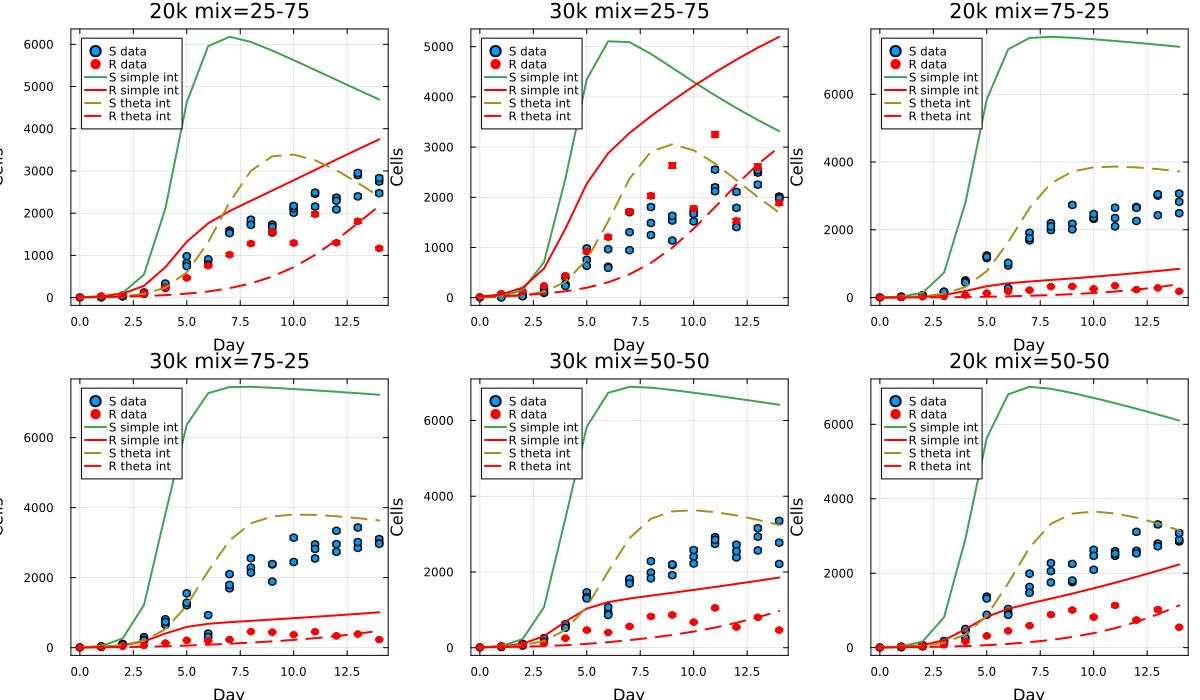

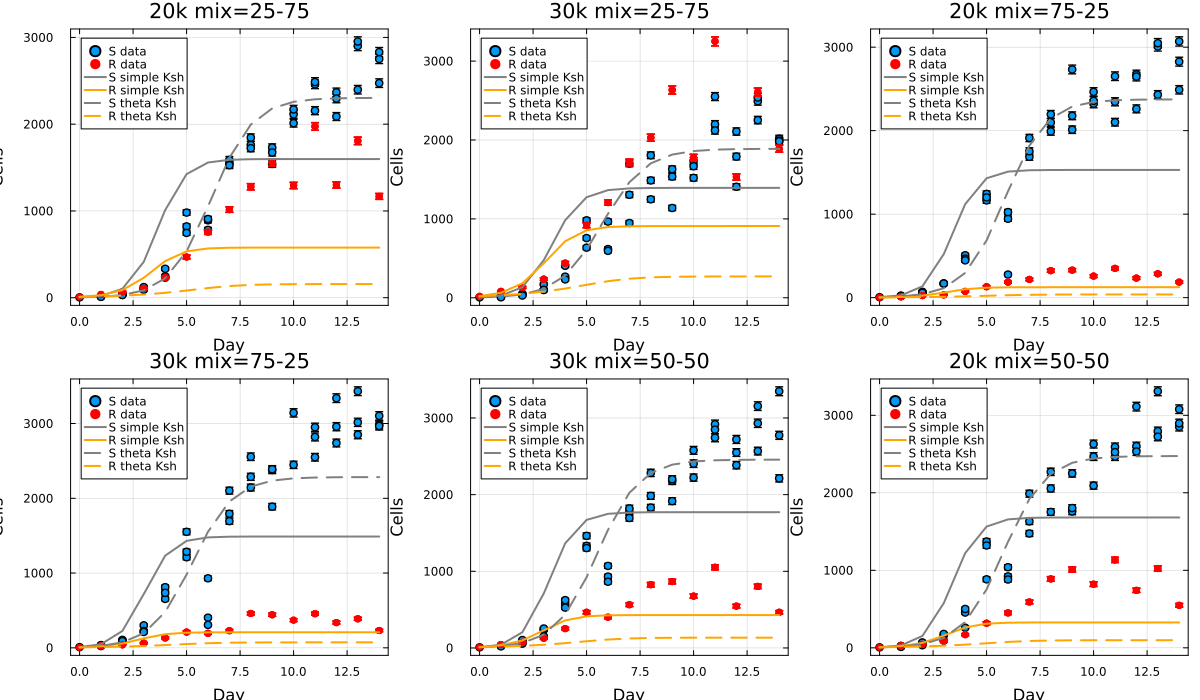

In [20]:
############################################################
# Untreated co-culture: simple vs theta baselines
# Models:
#   - competitive LV: dS = rS*S*(1 - (S + α_SR*R)/KS)^vS
#                     dR = rR*R*(1 - (α_RS*S + R)/KR)^vR
#   - shared K:       dS = rS*S*(1 - (S + R)/K_shared)^vS
#                     dR = rR*R*(1 - (S + R)/K_shared)^vR
############################################################

using CSV, DataFrames, Optim, Distributions, DifferentialEquations, Plots

# ------------------ ROOT ------------------
if !@isdefined ROOT
    ROOT = normpath(joinpath(pwd(), "..", ".."))
end
println("ROOT set to: ", ROOT)

# ------------------ Discover cis / non_cis files ------------------
function collect_coculture_pairs()
    base = joinpath(ROOT, "Processed_Datasets", "Untreated CoCulture")
    dens_list = ["20k", "30k"]
    types = ["cis", "non_cis"]
    recs = NamedTuple{(:density,:ctype,:path,:mix)}[]
    rx = r"measure_([0-9]+-[0-9]+)"i
    for d in dens_list, c in types
        dir = joinpath(base, d, c, "Averages")
        if !isdir(dir)
            @warn "Missing dir: $dir"
            continue
        end
        for f in readdir(dir; join=true)
            lf = lowercase(f)
            if !occursin("day_averages", lf) || !endswith(lf, ".csv")
                continue
            end
            m = match(rx, lf)
            mix = m === nothing ? "unknown" : m.captures[1]
            push!(recs, (density=d, ctype=c, path=f, mix=mix))
        end
    end
    pairs = NamedTuple{(:density,:mix,:cis_path,:noncis_path)}[]
    bykey = Dict{Tuple{String,String},Dict{String,String}}()
    for r in recs
        key = (r.density, r.mix)
        sub = get!(bykey, key, Dict{String,String}())
        sub[r.ctype] = r.path
    end
    for ((dens,mix), sub) in bykey
        cis_p  = get(sub, "cis", nothing)
        non_p  = get(sub, "non_cis", nothing)
        if cis_p === nothing || non_p === nothing
            @warn "Skipping pair (density=$dens, mix=$mix) missing cis or non_cis"
            continue
        end
        push!(pairs, (density=dens, mix=mix, cis_path=cis_p, noncis_path=non_p))
    end
    return pairs
end

coculture_pairs = collect_coculture_pairs()
isempty(coculture_pairs) && error("No cis/non_cis pairs found.")
println("Found $(length(coculture_pairs)) cis/non_cis pairs:")
for p in coculture_pairs
    println("  $(p.density) mix=$(p.mix): cis=$(p.cis_path), non_cis=$(p.noncis_path)")
end

# ------------------ Baselines ------------------
param_file_simple = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_all_models_parameters.csv")
param_file_theta  = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")
@assert isfile(param_file_simple) && isfile(param_file_theta)

function load_baselines(file; model_filter)
    df = CSV.read(file, DataFrame)
    if :Model in names(df)
        df = filter(row -> lowercase(String(row.Model)) == lowercase(model_filter), df)
    end
    params = Dict{Symbol,Tuple{Float64,Float64,Float64}}()
    for row in eachrow(df)
        v_val = :v in names(df) ? try Float64(row[:v]) catch; NaN end : NaN
        if isnan(v_val); v_val = 1.0; end
        params[Symbol(row[:CellLine])] = (Float64(row[:r]), Float64(row[:K]), v_val)
    end
    return params
end

baseline_simple = load_baselines(param_file_simple; model_filter="logistic")
baseline_theta  = load_baselines(param_file_theta;  model_filter="theta_logistic")

cellkey(ctype::String) = lowercase(ctype) == "cis" ? :A2780cis : :A2780Naive

# ------------------ Load series ------------------
function load_series(path)
    df = CSV.read(path, DataFrame)
    day_col  = findfirst(n -> lowercase(String(n)) == "day", names(df))
    mean_col = findfirst(n -> occursin("mean", lowercase(String(n))), names(df))
    @assert day_col !== nothing && mean_col !== nothing "Expected Day + mean column in $path"
    x = Float64.(df[!, day_col]); y = Float64.(df[!, mean_col])
    stderr = zeros(length(y)) .+ sqrt.(y .+ 1e-6)  # crude fallback
    p = sortperm(x); x, y, stderr = x[p], y[p], stderr[p]
    if minimum(x) > 0.1
        x = vcat([0.0], x); y = vcat([max(1.0, y[1]*0.25)], y); stderr = vcat([max(1.0, sqrt(y[1]))], stderr)
    end
    mask = x .<= 14.0
    return (t=x[mask], y=y[mask], yerr=stderr[mask], y0=y[mask][1])
end

# ------------------ Models ------------------
function simulate_competing(t, params, rS, KS, vS, rR, KR, vR, S0, R0)
    αSR, αRS = params
    αSR = clamp(αSR, 0.0, 1.0); αRS = clamp(αRS, 0.0, 1.0)
    function f!(du,u,p_,τ)
        S, R = u
        du[1] = rS * S * (1 - (S + αSR*R)/KS)^vS
        du[2] = rR * R * (1 - (αRS*S + R)/KR)^vR
    end
    prob = ODEProblem(f!, [S0,R0], (minimum(t), maximum(t)))
    sol = solve(prob; saveat=t, reltol=1e-6, abstol=1e-8)
    return getindex.(sol.u, 1), getindex.(sol.u, 2)
end

function simulate_sharedK(t, params, rS, vS, rR, vR, K_shared, S0, R0)
    Ksh = clamp(params[1], 10.0, 1e6)
    function f!(du,u,p_,τ)
        S, R = u
        du[1] = rS * S * (1 - (S + R)/Ksh)^vS
        du[2] = rR * R * (1 - (S + R)/Ksh)^vR
    end
    prob = ODEProblem(f!, [S0,R0], (minimum(t), maximum(t)))
    sol = solve(prob; saveat=t, reltol=1e-6, abstol=1e-8)
    return getindex.(sol.u, 1), getindex.(sol.u, 2)
end

# ------------------ Fit helper ------------------
function fit_pair(model_name, t, yS, eS, yR, eR;
                  rS, KS, vS, rR, KR, vR,
                  n_starts=12)
    n_obs = length(yS) + length(yR)
    kpar = model_name == :competing ? 2 : 1

    function loss(p)
        p_cl = model_name == :competing ?
               [clamp(p[1],0,1), clamp(p[2],0,1)] :
               [clamp(p[1],10,1e6)]
        yS_pred, yR_pred = model_name == :competing ?
                           simulate_competing(t, p_cl, rS, KS, vS, rR, KR, vR, yS[1], yR[1]) :
                           simulate_sharedK(t, p_cl, rS, vS, rR, vR, KS, yS[1], yR[1])
        if length(yS_pred)!=length(yS) || length(yR_pred)!=length(yR); return 1e12 end
        wS = 1.0 ./ (eS.^2 .+ 1e-12); wR = 1.0 ./ (eR.^2 .+ 1e-12)
        return sum(wS .* (yS_pred .- yS).^2) + sum(wR .* (yR_pred .- yR).^2)
    end

    best_val = Inf; best_p = nothing
    lower = model_name == :competing ? [0.0, 0.0] : [10.0]
    upper = model_name == :competing ? [1.0, 1.0] : [1e6]
    for _ in 1:n_starts
        init = model_name == :competing ?
               [rand(Uniform(0,1)), rand(Uniform(0,1))] :
               [rand(Uniform(min(KS,KR)/2, max(KS,KR)*2))]
        res = Optim.optimize(loss, lower, upper, init,
                             Fminbox(NelderMead()),
                             Optim.Options(iterations=400, show_trace=false))
        val = Optim.minimum(res)
        if val < best_val
            best_val = val; best_p = Optim.minimizer(res)
        end
    end
    sse = best_val
    s2  = sse / n_obs
    bic = n_obs*log(s2) + kpar*log(n_obs)
    aic = n_obs*log(s2) + 2kpar
    return (p̂=best_p, sse=sse, bic=bic, aic=aic)
end

# ------------------ Align helper ------------------
function align_on_common_times(S, R)
    tol = 1e-6
    common = Float64[]; idxS = Int[]; idxR = Int[]
    for (i, ts) in enumerate(S.t)
        j = findfirst(tr -> abs(tr - ts) < tol, R.t)
        if j !== nothing
            push!(common, ts); push!(idxS, i); push!(idxR, j)
        end
    end
    @assert !isempty(common) "No overlapping time points."
    return (t = collect(common),
            yS = S.y[idxS], eS = S.yerr[idxS],
            yR = R.y[idxR], eR = R.yerr[idxR])
end

fmt_params(tag::Symbol, p) = tag == :competing ?
    "alpha_SR=$(round(p[1],digits=4)), alpha_RS=$(round(p[2],digits=4))" :
    "K_shared=$(round(p[1],digits=2))"

# ------------------ Run fits ------------------
summary = DataFrame(density=String[], mix=String[], baseline=String[], model=String[],
                    bic=Float64[], aic=Float64[], sse=Float64[], params=String[])

for p in coculture_pairs
    S_series = load_series(p.noncis_path)
    R_series = load_series(p.cis_path)
    aligned = align_on_common_times(S_series, R_series)
    t, yS, eS, yR, eR = aligned.t, aligned.yS, aligned.eS, aligned.yR, aligned.eR

    for (baseline_name, baselines) in [("simple", baseline_simple), ("theta", baseline_theta)]
        kS = cellkey("non_cis"); kR = cellkey("cis")
        if !haskey(baselines, kS) || !haskey(baselines, kR)
            @warn "Baseline missing for $(baseline_name)"; continue
        end
        rS, KS, vS = baselines[kS]; rR, KR, vR = baselines[kR]
        vS = isnan(vS) ? 1.0 : vS; vR = isnan(vR) ? 1.0 : vR

        resC = fit_pair(:competing, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
        push!(summary, (p.density, p.mix, baseline_name, "competitive",
                        resC.bic, resC.aic, resC.sse, fmt_params(:competing, resC.p̂)))

        resK = fit_pair(:sharedK, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
        push!(summary, (p.density, p.mix, baseline_name, "sharedK",
                        resK.bic, resK.aic, resK.sse, fmt_params(:sharedK, resK.p̂)))
    end
end

sort!(summary, [:density, :mix, :baseline, :model])
println("\n=== Co-culture untreated: BIC/AIC/SSE, simple vs theta, all mixes ===")
show(summary, allrows=true, allcols=true)

# ------------------ Optional separate plots ------------------
function plot_grid_model(pairs; model::Symbol, title_prefix::String, max_plots::Int=6)
    plt = plot(layout=(2,3), size=(1200,700), title=title_prefix, legend=:topleft)
    n = min(length(pairs), max_plots)
    for i in 1:n
        p = pairs[i]
        S = load_series(p.noncis_path)
        R = load_series(p.cis_path)
        A = align_on_common_times(S, R)
        t, yS, eS, yR, eR = A.t, A.yS, A.eS, A.yR, A.eR

        scatter!(plt[i], t, yS; yerror=eS, label="S data", markersize=4)
        scatter!(plt[i], t, yR; yerror=eR, label="R data", markersize=4, markerstrokecolor=:red, markercolor=:red)

        for (label, baselines, ls) in [("simple", baseline_simple, :solid),
                                       ("theta",  baseline_theta,  :dash)]
            rS, KS, vS = baselines[:A2780Naive]; rR, KR, vR = baselines[:A2780cis]
            vS = isnan(vS) ? 1.0 : vS; vR = isnan(vR) ? 1.0 : vR

            if model == :competing
                res = fit_pair(:competing, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
                yS_fit, yR_fit = simulate_competing(t, res.p̂, rS, KS, vS, rR, KR, vR, yS[1], yR[1])
                plot!(plt[i], t, yS_fit; label="S $(label) int",  lw=2, ls=ls)
                plot!(plt[i], t, yR_fit; label="R $(label) int",  lw=2, ls=ls, color=:red)
            else
                res = fit_pair(:sharedK, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
                yS_fit, yR_fit = simulate_sharedK(t, res.p̂, rS, vS, rR, vR, KS, yS[1], yR[1])
                plot!(plt[i], t, yS_fit; label="S $(label) Ksh", lw=2, ls=ls, color=:gray)
                plot!(plt[i], t, yR_fit; label="R $(label) Ksh", lw=2, ls=ls, color=:orange)
            end
        end

        title!(plt[i], "$(p.density) mix=$(p.mix)")
        xlabel!(plt[i], "Day"); ylabel!(plt[i], "Cells")
    end
    display(plt)
end

# Uncomment to view:
plot_grid_model(coculture_pairs; model=:competing, title_prefix="Interaction (competitive) fits", max_plots=6)
plot_grid_model(coculture_pairs; model=:sharedK,   title_prefix="Shared-K fits",           max_plots=6)


In [21]:
############################################################
# Co-culture untreated summary: with vs without interaction
# Simple vs Theta baselines
############################################################

using CSV, DataFrames, Optim, Distributions, Plots

# expect: ROOT already defined, baseline_simple/theta already loaded,
# load_series, align_on_common_times, fit_pair, fmt_params, pairs, etc.
@assert @isdefined(ROOT)
@assert @isdefined(baseline_simple) && @isdefined(baseline_theta)
@assert @isdefined(load_series) && @isdefined(align_on_common_times)
@assert @isdefined(fit_pair) && @isdefined(fmt_params) && @isdefined(pairs)

function summarize_pairs(pairs; baselines_simple, baselines_theta)
    rows = NamedTuple[]
    for p in pairs
        S = load_series(p.noncis_path)  # Naive
        R = load_series(p.cis_path)     # cis
        A = align_on_common_times(S, R)
        t, yS, eS, yR, eR = A.t, A.yS, A.eS, A.yR, A.eR
        for (baseline_name, baselines) in [("simple", baselines_simple), ("theta", baselines_theta)]
            kS, kR = :A2780Naive, :A2780cis
            if !haskey(baselines, kS) || !haskey(baselines, kR)
                @warn "Missing baseline for $(baseline_name)"; continue
            end
            rS, KS, vS = baselines[kS]; rR, KR, vR = baselines[kR]
            vS = isnan(vS) ? 1.0 : vS; vR = isnan(vR) ? 1.0 : vR

            # with interaction (competitive)
            resC = fit_pair(:competing, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
            push!(rows, (density=p.density, mix=p.mix, cell="Naive+c i s", baseline=baseline_name,
                         interaction="with", model="competitive",
                         bic=resC.bic, params=fmt_params(:competing, resC.p̂)))

            # without interaction (shared K)
            resK = fit_pair(:sharedK, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
            push!(rows, (density=p.density, mix=p.mix, cell="Naive+c i s", baseline=baseline_name,
                         interaction="without", model="sharedK",
                         bic=resK.bic, params=fmt_params(:sharedK, resK.p̂)))
        end
    end
    return DataFrame(rows)
end

df_all = summarize_pairs(pairs; baselines_simple=baseline_simple, baselines_theta=baseline_theta)

# collapse to desired view: Naive/Cis × density, Simple vs Theta params, per interaction mode
function make_view(df; interaction_mode)
    sub = filter(r -> r.interaction == interaction_mode, df)
    # pick the best (lowest BIC) per density × baseline
    best = combine(groupby(sub, [:density, :baseline])) do g
        g[argmin(g.bic), :]
    end
    function row_for(dens, celllabel)
        srow = best[(best.density .== dens) .& (best.baseline .== "simple"), :]
        trow = best[(best.density .== dens) .& (best.baseline .== "theta"), :]
        sparams = nrow(srow)==1 ? srow.params[1] : "n/a"
        tparams = nrow(trow)==1 ? trow.params[1] : "n/a"
        sbic    = nrow(srow)==1 ? srow.bic[1]    : NaN
        tbic    = nrow(trow)==1 ? trow.bic[1]    : NaN
        return (row=celllabel, simple_params=sparams, theta_params=tparams,
                simple_bic=sbic, theta_bic=tbic)
    end
    rows = [
        row_for("20k", "Naive 20k"),
        row_for("20k", "Cis 20k"),
        row_for("30k", "Naive 30k"),
        row_for("30k", "Cis 30k"),
    ]
    tbl = DataFrame(rows)
    push!(tbl, ("Total BIC",
                "", "",
                sum(skipmissing(tbl.simple_bic)),
                sum(skipmissing(tbl.theta_bic))))
    return tbl
end

table_with    = make_view(df_all; interaction_mode="with")
table_without = make_view(df_all; interaction_mode="without")

println("\n=== WITH interaction (competitive) ===")
show(table_with, allrows=true, allcols=true)
println("\n=== WITHOUT interaction (shared K) ===")
show(table_without, allrows=true, allcols=true)

# ----------------- Quick plots -----------------
println("\nPlotting overlays (with vs without) for first 6 pairs...")

function plot_overlays(pairs, df; max_plots=6)
    plt = plot(layout=(2,3), size=(1200, 700))
    n = min(length(pairs), max_plots)
    for i in 1:n
        p = pairs[i]
        S = load_series(p.noncis_path); R = load_series(p.cis_path)
        A = align_on_common_times(S, R)
        t, yS, eS, yR, eR = A.t, A.yS, A.eS, A.yR, A.eR

        # best simple/theta per interaction
        for (label, baselines, ls) in [("simple", baseline_simple, :solid),
                                       ("theta",  baseline_theta,  :dash)]
            rS, KS, vS = baselines[:A2780Naive]; rR, KR, vR = baselines[:A2780cis]
            vS = isnan(vS) ? 1.0 : vS; vR = isnan(vR) ? 1.0 : vR
            resC = fit_pair(:competing, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
            resK = fit_pair(:sharedK,   t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
            yS_c, yR_c = simulate_competing(t, resC.p̂, rS, KS, vS, rR, KR, vR, yS[1], yR[1])
            yS_k, yR_k = simulate_sharedK(t, resK.p̂, rS, vS, rR, vR, KS, yS[1], yR[1])
            idx = i
            scatter!(plt[idx], t, yS; yerror=eS, label="S data"*(i==1 && label=="simple" ? "" : ""), markersize=4)
            scatter!(plt[idx], t, yR; yerror=eR, label="R data"*(i==1 && label=="simple" ? "" : ""), markersize=4, markerstrokecolor=:red, markercolor=:red)
            plot!(plt[idx], t, yS_c; label="S $(label) with int", lw=2, ls=ls)
            plot!(plt[idx], t, yR_c; label="R $(label) with int", lw=2, ls=ls, color=:red)
            plot!(plt[idx], t, yS_k; label="S $(label) no int", lw=2, ls=ls, color=:gray)
            plot!(plt[idx], t, yR_k; label="R $(label) no int", lw=2, ls=ls, color=:orange)
            title!(plt[idx], "$(p.density) mix=$(p.mix)")
            xlabel!(plt[idx], "Day"); ylabel!(plt[idx], "Cells")
        end
    end
    display(plt)
end

plot_overlays(pairs, df_all; max_plots=6)


MethodError: MethodError: no method matching iterate(::typeof(pairs))

Closest candidates are:
  iterate(!Matched::RegexMatch, Any...)
   @ Base regex.jl:284
  iterate(!Matched::LibGit2.GitRevWalker)
   @ LibGit2 C:\Users\elbak\AppData\Local\Programs\Julia-1.10.9\share\julia\stdlib\v1.10\LibGit2\src\walker.jl:29
  iterate(!Matched::LibGit2.GitRevWalker, !Matched::Any)
   @ LibGit2 C:\Users\elbak\AppData\Local\Programs\Julia-1.10.9\share\julia\stdlib\v1.10\LibGit2\src\walker.jl:29
  ...


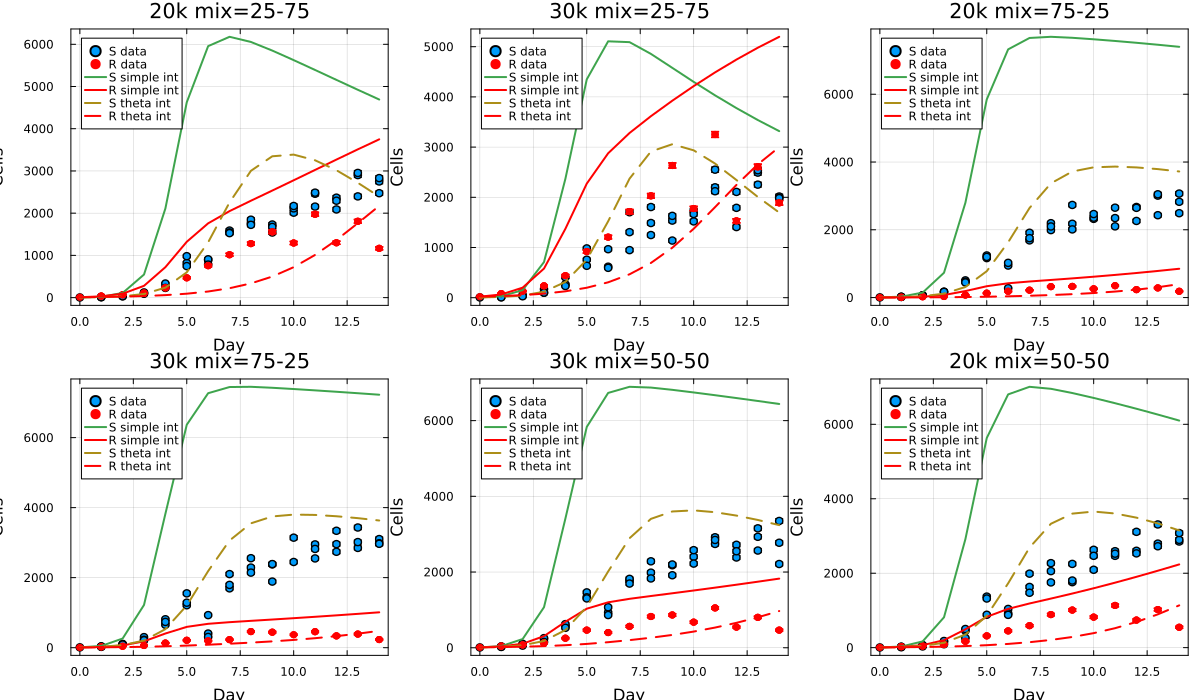

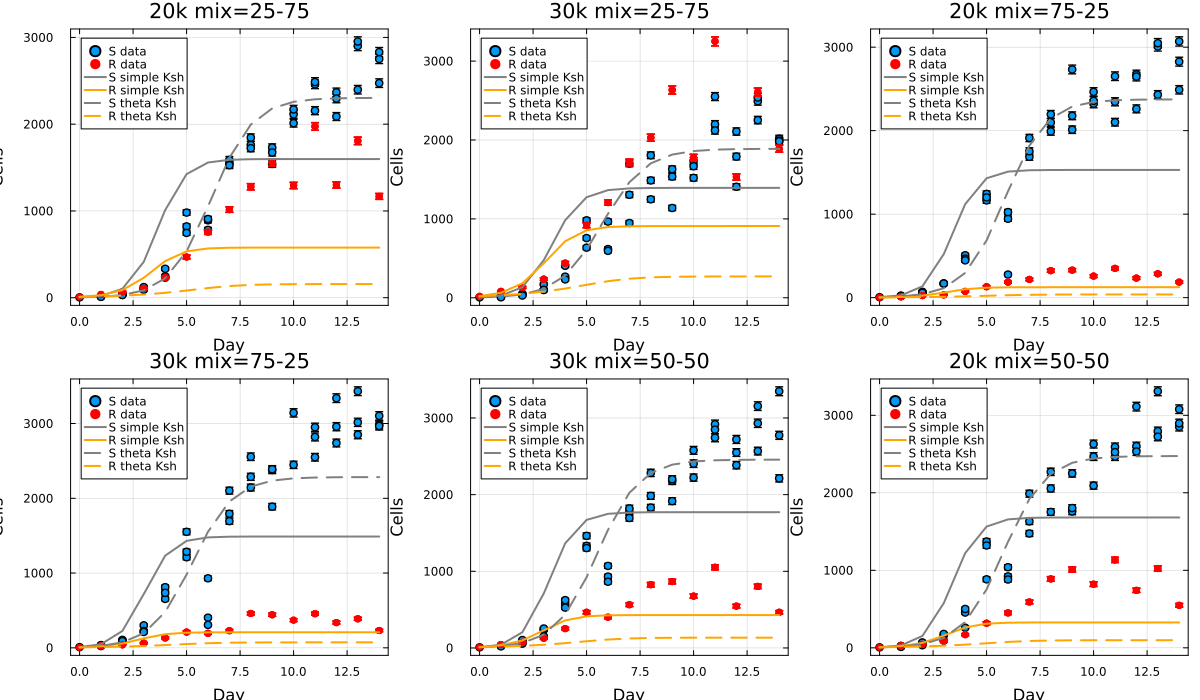

In [23]:
############################################################
# Fit helper, align helper, and separate grids (int vs Kshared)
############################################################

using Optim, Distributions, Plots

# Fit helper (tight interaction bounds)
function fit_pair(model_name, t, yS, eS, yR, eR;
                  rS, KS, vS, rR, KR, vR,
                  n_starts=12)
    n_obs = length(yS) + length(yR)
    kpar = model_name == :competing ? 2 : 1

    function loss(p)
        p_cl = model_name == :competing ?
               [clamp(p[1], 0.0, 1.0), clamp(p[2], 0.0, 1.0)] :
               [clamp(p[1], 10.0, 1e6)]
        yS_pred, yR_pred = model_name == :competing ?
                           simulate_competing(t, p_cl, rS, KS, vS, rR, KR, vR, yS[1], yR[1]) :
                           simulate_sharedK(t, p_cl, rS, vS, rR, vR, KS, yS[1], yR[1])
        if length(yS_pred)!=length(yS) || length(yR_pred)!=length(yR); return 1e12 end
        wS = 1.0 ./ (eS.^2 .+ 1e-12); wR = 1.0 ./ (eR.^2 .+ 1e-12)
        return sum(wS .* (yS_pred .- yS).^2) + sum(wR .* (yR_pred .- yR).^2)
    end

    best_val = Inf; best_p = nothing
    lower = model_name == :competing ? [0.0, 0.0] : [10.0]
    upper = model_name == :competing ? [1.0, 1.0] : [1e6]

    for _ in 1:n_starts
        init = model_name == :competing ?
               [rand(Uniform(0,1)), rand(Uniform(0,1))] :
               [rand(Uniform(min(KS,KR)/2, max(KS,KR)*2))]
        res = Optim.optimize(loss, lower, upper, init,
                             Fminbox(NelderMead()),
                             Optim.Options(iterations=400, show_trace=false))
        val = Optim.minimum(res)
        if val < best_val
            best_val = val
            best_p = Optim.minimizer(res)
        end
    end

    sse = best_val
    s2  = sse / n_obs
    bic = n_obs*log(s2) + kpar*log(n_obs)
    aic = n_obs*log(s2) + 2kpar
    return (p̂=best_p, sse=sse, bic=bic, aic=aic)
end

# Align helper
function align_on_common_times(S, R)
    tol = 1e-6
    common = Float64[]; idxS = Int[]; idxR = Int[]
    for (i, ts) in enumerate(S.t)
        j = findfirst(tr -> abs(tr - ts) < tol, R.t)
        if j !== nothing
            push!(common, ts); push!(idxS, i); push!(idxR, j)
        end
    end
    @assert !isempty(common) "No overlapping time points."
    return (t = collect(common),
            yS = S.y[idxS], eS = S.yerr[idxS],
            yR = R.y[idxR], eR = R.yerr[idxR])
end

# Separate grids: interaction vs shared-K
function plot_grid_model(coculture_pairs; model::Symbol, title_prefix::String, max_plots::Int=6)
    plt = plot(layout=(2,3), size=(1200,700), title=title_prefix, legend=:topleft)
    n = min(length(coculture_pairs), max_plots)
    for i in 1:n
        p = coculture_pairs[i]
        S = load_series(p.noncis_path)
        R = load_series(p.cis_path)
        A = align_on_common_times(S, R)
        t, yS, eS, yR, eR = A.t, A.yS, A.eS, A.yR, A.eR

        scatter!(plt[i], t, yS; yerror=eS, label="S data", markersize=4)
        scatter!(plt[i], t, yR; yerror=eR, label="R data", markersize=4,
                 markerstrokecolor=:red, markercolor=:red)

        for (label, baselines, ls) in [("simple", baseline_simple, :solid),
                                       ("theta",  baseline_theta,  :dash)]
            rS, KS, vS = baselines[:A2780Naive]; rR, KR, vR = baselines[:A2780cis]
            vS = isnan(vS) ? 1.0 : vS; vR = isnan(vR) ? 1.0 : vR

            if model == :competing
                res = fit_pair(:competing, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
                yS_fit, yR_fit = simulate_competing(t, res.p̂, rS, KS, vS, rR, KR, vR, yS[1], yR[1])
                plot!(plt[i], t, yS_fit; label="S $(label) int",  lw=2, ls=ls)
                plot!(plt[i], t, yR_fit; label="R $(label) int",  lw=2, ls=ls, color=:red)
            else
                res = fit_pair(:sharedK, t, yS, eS, yR, eR; rS=rS, KS=KS, vS=vS, rR=rR, KR=KR, vR=vR)
                yS_fit, yR_fit = simulate_sharedK(t, res.p̂, rS, vS, rR, vR, KS, yS[1], yR[1])
                plot!(plt[i], t, yS_fit; label="S $(label) Ksh", lw=2, ls=ls, color=:gray)
                plot!(plt[i], t, yR_fit; label="R $(label) Ksh", lw=2, ls=ls, color=:orange)
            end
        end

        title!(plt[i], "$(p.density) mix=$(p.mix)")
        xlabel!(plt[i], "Day"); ylabel!(plt[i], "Cells")
    end
    display(plt)
end

# Run both grids (adjust max_plots if desired)
plot_grid_model(coculture_pairs; model=:competing, title_prefix="Interaction (competitive) fits", max_plots=6)
plot_grid_model(coculture_pairs; model=:sharedK,   title_prefix="Shared-K fits",           max_plots=6)
